In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('career_path.csv')
# df = df.drop(columns=['Unnamed: 0'])
df.head()

,Internships,Projects,Leadership_Positions,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,SVD1,SVD2,SVD3,Final_Cluster
0,0,2,0,4,2,2,1,0,1,1.480914,0.750548,0.808229,0
1,2,0,0,4,0,3,0,3,0,1.488576,0.746523,-0.563753,4
2,0,0,0,1,1,2,2,3,4,1.480948,0.749898,0.743916,0
3,1,3,0,1,3,1,2,1,2,1.476182,0.734913,-0.218897,2
4,2,4,0,4,3,4,4,3,2,1.485435,0.766852,-0.664286,4


In [6]:
print(df.shape)

(9000, 13)


In [7]:
df.isnull().sum()

Internships               0
Projects                  0
Leadership_Positions      0
Communication_Skills      0
Problem_Solving_Skills    0
Teamwork_Skills           0
Analytical_Skills         0
Presentation_Skills       0
Networking_Skills         0
SVD1                      0
SVD2                      0
SVD3                      0
Final_Cluster             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(67)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Internships             9000 non-null   int64  
 1   Projects                9000 non-null   int64  
 2   Leadership_Positions    9000 non-null   int64  
 3   Communication_Skills    9000 non-null   int64  
 4   Problem_Solving_Skills  9000 non-null   int64  
 5   Teamwork_Skills         9000 non-null   int64  
 6   Analytical_Skills       9000 non-null   int64  
 7   Presentation_Skills     9000 non-null   int64  
 8   Networking_Skills       9000 non-null   int64  
 9   SVD1                    9000 non-null   float64
 10  SVD2                    9000 non-null   float64
 11  SVD3                    9000 non-null   float64
 12  Final_Cluster           9000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 914.2 KB


In [10]:
cat_cols = df.columns

In [11]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_encoded = encoder.fit_transform(df[cat_cols])

In [12]:
from sklearn.decomposition import TruncatedSVD

svd2 = TruncatedSVD(n_components=3, random_state=42)
X_final = svd2.fit_transform(X_encoded)

print(X_final.shape)   # should be (rows, 2)

(9000, 3)


In [13]:
X_final

array([[ 1.5326406 ,  0.85186222,  0.96896568],
       [ 1.54047085,  0.86228439, -0.74038083],
       [ 1.53267031,  0.85341465,  0.92532317],
       ...,
       [ 1.54265257,  0.84348449,  1.01407182],
       [ 1.55507344, -0.81327324,  0.95378392],
       [ 1.54051048,  0.84515679, -0.13049546]], shape=(9000, 3))

In [14]:
from sklearn.cluster import KMeans

wcss = []

K_range = range(2, 15)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=30,
        random_state=42
    )
    km.fit(X_final)
    wcss.append(km.inertia_)


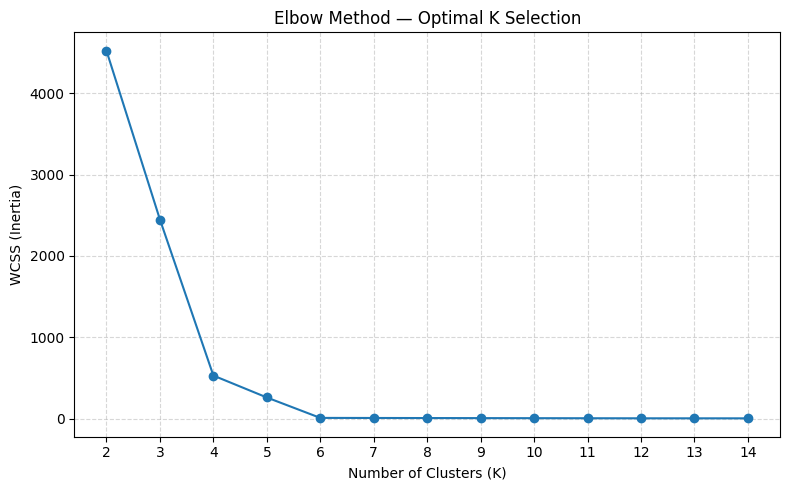

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method — Optimal K Selection")
plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=6, n_init=30, random_state=42)
labels = kmeans.fit_predict(X_final)

print("Silhouette:", silhouette_score(X_final, labels))


Silhouette: 0.9405379135420513


In [17]:
df["Final_Cluster"] = labels

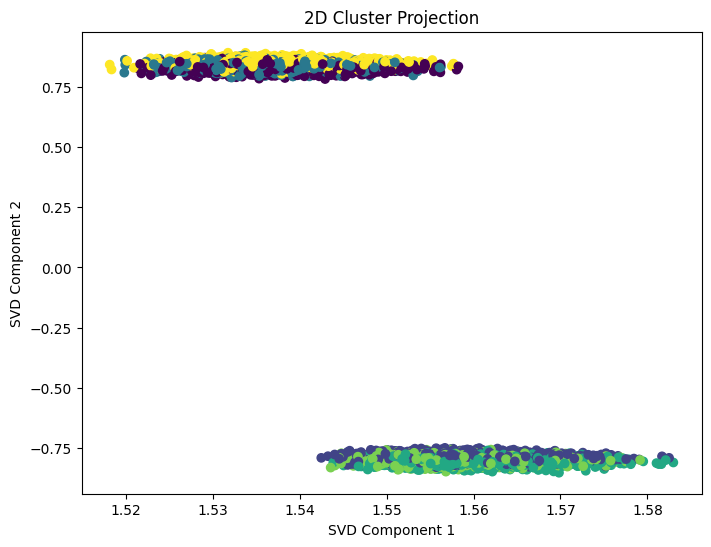

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_final[:,0], X_final[:,1], c=labels)
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("2D Cluster Projection")
plt.show()


In [19]:
svd3 = TruncatedSVD(n_components=3, random_state=42)
X_vis3D = svd3.fit_transform(X_encoded)

df["SVD1"] = X_vis3D[:,0]
df["SVD2"] = X_vis3D[:,1]
df["SVD3"] = X_vis3D[:,2]


In [20]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="SVD1",
    y="SVD2",
    z="SVD3",
    color="Final_Cluster",
    title="3D Cluster Visualization (SVD + KMeans)"
)

fig.show()

In [21]:
# Save results for the Meta-Model
df.to_csv('career_path.csv', index=False)
print("Career results exported to career_path.csv")

Career results exported to career_path.csv


In [22]:
import pickle
with open('career_path_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)